# Gaussian solutions

In this notebook the steady state of the Fokker-Planck equation is:

$u = \alpha e^{\beta V\left(\left\|x\right\|^2\right)}$

The used equations are:

- SDE: $ dX_t = \left(-\nabla_x V\left(\left\|X_t\right\|^2\right) + RX_t\right)dt + \sigma^2 dW_t $
- Fokker-Planck: $ u_t = - \sum_i \left(\left(-\nabla_x V\left(\left\|x\right\|^2\right) + Rx\right)_i u\right)_{x_i} + \sigma^2\frac12\sum_{ij} u_{x_ix_j} $

where $R$ is an antisymmetric matrix and $\sigma$ is a constant.

**proof**

We can prove that:

$ u_t = - \sum_i \left(u f_i\right)_{x_i} + \frac12\sum_{ij} {u\Sigma_{ij}}_{x_ix_j} = \left[u, \nabla_x u, \frac12\nabla_x^2 u\right]\cdot\left[\frac12\nabla_x^2\cdot\Sigma-\nabla_x\cdot f, \nabla_x\cdot\Sigma-f, \Sigma\right]$

In this context:
- $\nabla_x V\left(\left\|x\right\|^2\right) = 2V'\left(\left\|x\right\|^2\right)x $ 
- $\nabla_x^2 V\left(\left\|x\right\|^2\right) = 4V''\left(\left\|x\right\|^2\right)xx^T + 2V'\left(\left\|x\right\|^2\right)\text{Id} $
- $\nabla_x u = \nabla_x \alpha e^{\beta V\left(\left\|x\right\|^2\right)} = \beta \nabla_x V\left(\left\|x\right\|^2\right) u = 2 \beta u V'\left(\left\|x\right\|^2\right)x $
- $\nabla_x^2 u = \nabla_x \beta \nabla_x V\left(\left\|x\right\|^2\right) u = \beta u \left[\nabla_x^2 V\left(\left\|x\right\|^2\right) + \beta \nabla_x V\left(\left\|x\right\|^2\right)\nabla_x V\left(\left\|x\right\|^2\right)^T \right] = \beta u \left[4V''\left(\left\|x\right\|^2\right)xx^T + 2V'\left(\left\|x\right\|^2\right)\text{Id} + 4 \beta V'\left(\left\|x\right\|^2\right)^2xx^T \right] $
- $\left[\frac12\nabla_x^2\cdot\Sigma-\nabla_x\cdot f, \nabla_x\cdot\Sigma-f, \Sigma\right] = \left[-\nabla_x\cdot f, -f, \Sigma\right] = \left[\Delta_x V\left(\left\|x\right\|^2\right), \nabla_x V\left(\left\|x\right\|^2\right) - Rx, \sigma^2\text{Id}\right] = \left[4 V''\left(\left\|x\right\|^2\right)\left\|x\right\|^2 + 2dV'\left(\left\|x\right\|^2\right), 2V'\left(\left\|x\right\|^2\right)x - Rx, \sigma^2\text{Id}\right] $
- $ \left(2V'\left(\left\|x\right\|^2\right)x - Rx\right) \cdot 2 \beta u V'\left(\left\|x\right\|^2\right)x = 4\beta u V'\left(\left\|x\right\|^2\right)^2\left\|x\right\|^2 $
- $ \sigma^2\text{Id}\cdot\frac{\beta}{2} u \left[4V''\left(\left\|x\right\|^2\right)xx^T + 2V'\left(\left\|x\right\|^2\right)\text{Id} + 4 \beta V'\left(\left\|x\right\|^2\right)^2xx^T \right] = 4\beta\frac{\sigma^2}{2} u V''\left(\left\|x\right\|^2\right)\left\|x\right\|^2 + 2d\beta\frac{\sigma^2}{2} u V'\left(\left\|x\right\|^2\right) + 4 \beta^2\frac{\sigma^2}{2} u V'\left(\left\|x\right\|^2\right)^2\left\|x\right\|^2 $

So:

$ u_t = \left[u, \nabla_x u, \frac12\nabla_x^2 u\right]\cdot\left[\frac12\nabla_x^2\cdot\Sigma-\nabla_x\cdot f, \nabla_x\cdot\Sigma-f, \Sigma\right] = 4 u V''\left(\left\|x\right\|^2\right)\left\|x\right\|^2 + 2duV'\left(\left\|x\right\|^2\right) + 4\beta u V'\left(\left\|x\right\|^2\right)^2\left\|x\right\|^2 + 4\beta\frac{\sigma^2}{2} u V''\left(\left\|x\right\|^2\right)\left\|x\right\|^2 + 2d\beta\frac{\sigma^2}{2} u V'\left(\left\|x\right\|^2\right) + 4 \beta^2\frac{\sigma^2}{2} u V'\left(\left\|x\right\|^2\right)^2\left\|x\right\|^2 $

$ = u\left[4\left\|x\right\|^2\left(\beta V'\left(\left\|x\right\|^2\right)^2+V''\left(\left\|x\right\|^2\right)\right) + 2dV'\left(\left\|x\right\|^2\right)\right]\left(1+\beta\frac{\sigma^2}{2}\right) $


If $\frac{\beta\sigma^2}{2}=-1$ we have the thesis.

## Training

We want a neural network with parameters $\theta$ representd by $x\mapsto\tilde{u}(x,\theta)$ such that minimizes:

$$L(\theta) = \frac{1}{N^X}\sum_{i=1}^{N^X}(\mathcal{L}\tilde{u}(x_i,\theta))^2+\frac{1}{N^Y}\sum_{j=1}^{N^Y}(\tilde{u}(y_j,\theta)-v(y_j))^2:=L_1(\theta)+L_2(\theta)$$

where:
- $\theta$ is the set of parameters of the NN
- $x_i\in\mathbb{R}^n$ with $i=1,2,\ldots,N^X$
- $y_j\in\mathbb{R}^n$ with $j=1,2,\dots,N^Y$
- $v(y_j)$ is the solution of the MC approximation.

## Monte Carlo

Here we implement the function $v$, in the paper the authors report the procedure:

- A single trajectory for Euler-Maruyama numerical scheme with:
    - $10^7$ steps
    - the time step size is 0.001
    - empirical probability on a $200\times200$ mesh of the region $D = [−2,2] ×[−2,2]$
    - sampling from this trajectory 

In [1]:
# monte carlo implementation of the example in Zhai et al. (2022)
import numpy as np
from zhai2022.sde import Model
from zhai2022.sde.euler_maruyama import EulerMaruyama

R = np.array([[0,1],[-1,0]])

# Define drift, diffusion, and initial state functions
def drift(X, t):
    return - 4 * (np.linalg.norm(X, axis=-1, keepdims=True)**2-1) * X + np.einsum('ij, sj -> si', R, X)

def diffusion(X, t):
    return np.tile(np.eye(X.shape[1]), (X.shape[0], 1, 1))

def initial_state(n_samples):
    return np.zeros((n_samples, 2))

# Create a Model instance
model = Model(drift, diffusion, initial_state, initial_time=0.0, n_dim=2)

# burn-in: 10sec of real time simulation
dt_schedule = np.ones(int(10/0.001)) * 0.001
euler_maruyama = EulerMaruyama(model, dt_schedule)
X = euler_maruyama.get_end(n_samples=1)  # shape: (1, 2)

# start simulation for 10^7 samples
dt_schedule = np.ones(10**7) * 0.001
def new_init(n_samples):
    return np.ones((n_samples, 2)) * X
model = Model(drift, diffusion, new_init, initial_time=0.0, n_dim=2)
euler_maruyama = EulerMaruyama(model, dt_schedule)
Xtrj = euler_maruyama.get_trajectory(n_samples=1)  # shape: (n_time_steps, 1, n_dim)

The idea is simple:

after a burn-in (in this case with 10sec of real time simulation and starting point in $0$), the authors make a single trajectory with many steps and a long time. Although there is a dependency between one sample and the next, the union of all samples from a long real time (10^4 seconds) trajectory allows us to no longer recognize the trajectory and have samples of the final distribution.

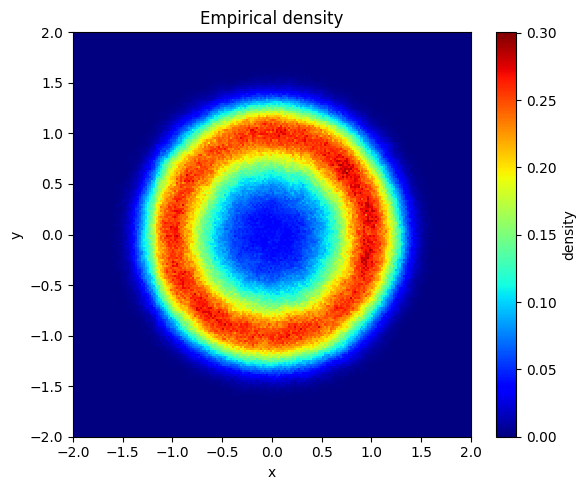

In [2]:
# see density
from matplotlib import pyplot as plt

# compute empirical density
x = Xtrj[:,0,0]
y = Xtrj[:,0,1]

# dominio e griglia
xmin, xmax = -2, 2
ymin, ymax = -2, 2
nx, ny = 200, 200   # come il paper

plt.figure(figsize=(6, 5))
counts, xedges, yedges, img = plt.hist2d(
    x, y,
    bins=[nx, ny],
    range=[[xmin, xmax], [ymin, ymax]],
    density=True,        # normalizza: somma ≈ 1
    cmap="jet",
    cmin=0,
)
plt.colorbar(label="density")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Empirical density")
plt.tight_layout()
plt.show()

In [3]:
def v(vec: np.ndarray):
    # vec has shape N,2
    mask = np.logical_and(
        np.logical_and(vec[:,0]>=xmin, vec[:,0]<xmax),
        np.logical_and(vec[:,1]>=ymin, vec[:,1]<ymax)
    )
    valid_vec = vec[mask]
    ix = np.searchsorted(xedges, valid_vec[:,0], side="right") - 1
    iy = np.searchsorted(yedges, valid_vec[:,1], side="right") - 1

    values = np.empty(vec.shape[0])

    values[mask] = counts[ix,iy]
    values[~mask] = 0.0

    return values

## Linear problem

Then, we have to compute $\mathcal{L}\tilde{u}\left(x,\theta\right)$

Here, I compute $\mathcal{L}(x,t)$ matrix with given model

$ u_t = -\sum_{i} (f_i u)_{x_i} + \frac12\sum_{ij} (\Sigma_{ij}u)_{x_ix_j} = \left[\frac12\nabla_x^2\cdot\Sigma-\nabla_x \cdot f, \nabla_x\cdot\Sigma-f, \Sigma\right]\cdot\left[u,\nabla_x u,\frac12\nabla_x^2 u\right] = \mathcal{L}u$

where:
- $\nabla_x^2\cdot\Sigma:=\sum_{ij} \partial_{x_ix_j}\Sigma_{ij}$
- $\nabla_x\cdot\Sigma:=\left(\nabla_x \cdot \Sigma_{n}\right)_n$

Indeed:
- $\sum_{i} (f_i u)_{x_i} = \sum_{i} (f_i)_{x_i}u + f_i u_{x_i} = u\nabla_x\cdot f + f \cdot \nabla_x u$
- $\frac12\sum_{ij} (\Sigma_{ij}u)_{x_ix_j} = \frac12\sum_{ij} (\Sigma_{ij})_{x_ix_j}u + \frac12\sum_{ij} (\Sigma_{ij})_{x_i}u_{x_j} + \frac12\sum_{ij} (\Sigma_{ij})_{x_j}u_{x_i} + \frac12\sum_{ij} \Sigma_{ij} u_{x_ix_j} = \frac12\nabla_x^2\cdot\Sigma u + \left(\nabla_x\cdot\Sigma\right) \cdot \nabla_x u + \frac12\Sigma\cdot\nabla_x^2u$

In this case we have:

$u_t = \left[-\nabla_x \cdot f, -f, \Sigma\right]\cdot\left[u,\nabla_x u,\frac12\nabla_x^2 u\right]$

where:
- $ f = -\nabla_x V(\left\|x\right\|^2) + Rx= -2V'(\left\|x\right\|^2)x + Rx = -4x\left(\left\|x\right\|^2-1\right)+Rx $ with $V(r^2)=(r^2-1)^2$
- $\nabla_x\cdot f = -\Delta_x V(\left\|x\right\|^2) = -4V''(\left\|x\right\|^2)\left\|x\right\|^2 - 2dV'(\left\|x\right\|^2) = 4\left(d-(2+d)\left\|x\right\|^2\right)$

In this way we can prove that $u=e^{-2\frac{V\left(\left\|x\right\|^2\right)}{\sigma^2}}$ is the solution:
- $\nabla_x V(\left\|x\right\|^2) = 2V'(\left\|x\right\|^2)x$
- $\nabla_x^2 V(\left\|x\right\|^2) = 4V''(\left\|x\right\|^2)x^Tx + 2V'(\left\|x\right\|^2)\text{Id}$
- $\Delta_x V(\left\|x\right\|^2) = 4V''(\left\|x\right\|^2)\left\|x\right\|^2 + 2dV'(\left\|x\right\|^2)$
- $u_x = -\frac{2}{\sigma^2}\nabla_x V\left(\left\|x\right\|^2\right)u = -\frac{4}{\sigma^2}uV'(\left\|x\right\|^2)x$
- $u_{xx} = -\frac{4}{\sigma^2}\left(\nabla_x^2 V\left(\left\|x\right\|^2\right)+\frac{-2}{\sigma^2}\left(\nabla_x V\left(\left\|x\right\|^2\right)\right)^T\nabla_x V\left(\left\|x\right\|^2\right)\right)e^{-2\frac{V\left(\left\|x\right\|^2\right)}{\sigma^2}} = \frac{-2}{\sigma^2}\left(\nabla_x^2 V\left(\left\|x\right\|^2\right)+\frac{-2}{\sigma^2}\left(\nabla_x V\left(\left\|x\right\|^2\right)\right)^T\nabla_x V\left(\left\|x\right\|^2\right)\right) u = \frac{-2}{\sigma^2}\left(V''(\left\|x\right\|^2)x^Tx + V'(\left\|x\right\|^2)\text{Id}+\frac{-2}{\sigma^2}V'(\left\|x\right\|^2)^2x^Tx\right) u $
- $\left[-\Delta_x V(\left\|x\right\|^2), \nabla_x V(\left\|x\right\|^2) - Rx, \sigma^2\right] \cdot \left[u,u_x,u_{xx}\right] = -\left(V''(\left\|x\right\|^2)\left\|x\right\|^2 + dV'(\left\|x\right\|^2)\right) u + \frac{-2u}{\sigma^2}V'(\left\|x\right\|^2)^2\left\|x\right\|^2$

The training requires an extimation of
$$\partial_\theta \mathcal{L}\tilde{u}\left(x,\theta\right) = \partial_\theta \left[\frac12\nabla_x^2\cdot\Sigma-\nabla_x \cdot f, \nabla_x\cdot\Sigma-f, \Sigma\right]\cdot\left[\tilde{u}_\theta,\nabla_x \tilde{u}_\theta,\frac12\nabla_x^2\tilde{u}_\theta\right] = \left[\frac12\nabla_x^2\cdot\Sigma-\nabla_x \cdot f, \nabla_x\cdot\Sigma-f, \Sigma\right]\cdot\partial_\theta\left[\tilde{u}_\theta,\nabla_x \tilde{u}_\theta,\frac12\nabla_x^2\tilde{u}_\theta\right]$$

So, in this example:
$\mathcal{L}\tilde{u} = \left[-\nabla_x \cdot f, -f, \Sigma\right]\cdot\left[\tilde{u},\tilde{u}_x,\frac12\tilde{u}_{xx}\right] = \left[-4\left(d-(2+d)\left\|x\right\|^2\right), -f, \Sigma\right]\cdot\left[\tilde{u},\tilde{u}_x,\frac12\tilde{u}_{xx}\right]$

In [ ]:
import torch
from typing import Callable
from zhai2022.differential import Differential


def L(sigma: float, f: Callable[[torch.Tensor], torch.Tensor], u: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor) -> torch.Tensor:
    # f: shape(N,2) -> shape(N,2)
    # u: shape(N,2) -> shape(N,)


    diff = Differential(1)
    diff2 = Differential(2)
    -diff.div(lambda y: u(y)*f(y))(x) + sigma**2/2 * diff2.div(lambda y: u(y)*torch.eye(2)[None,...])(x)


    diff2 = Differential(2)
    # _u shape = (N,)
    # d_u shape = (N,2)
    # d2_u shape = (N,2,2)
    _u, d_u, d2_u = diff2.nabla(u)(x, full_trace=True)

    # _f shape (N,2)
    # div_f shape (N,)
    R = torch.tensor([[0.0, -1.0],[1.0,0.0]])
    _f = - 4 * x * (torch.norm(x, dim=1, keepdim=True)**2-1) + torch.einsum('ij,sj->si',R,x)
    div_f = 4 * (2-4*torch.norm(x, dim=1, keepdim=True)**2)

    return (
        - torch.einsum('...,...->',div_f,_u) - torch.einsum('...,...->',_f,d_u) + sigma**2*torch.sum(d2_u)/2 
    )

In [8]:
import torch
from zhai2022.differential import Differential

R = torch.tensor([[0.0, -1.0],[1.0,0.0]])
def f(x: torch.Tensor) -> torch.Tensor:
    return - 4 * x * (torch.norm(x, dim=1, keepdim=True)**2-1) + torch.einsum('ij,sj->si',R,x)
sigma = 1.0
def Sigma(x: torch.Tensor) -> torch.Tensor:
    return sigma**2 * torch.eye(2)[None, ...].repeat(x.shape[0], 1, 1)
x = torch.rand(1,2)
def u(x: torch.Tensor) -> torch.Tensor:
    return torch.exp(-2.0*(torch.norm(x, dim=1)**2-1)**2)

# x:shape (N,2)
# u: shape (N,)
# f: shape (N,2)
# Sigma: shape (N,2,2)

# verifico i calcoli
diff = Differential(1)
print(diff.div(lambda y: u(y)*f(y))(x))
print(torch.einsum('si,si->s',diff.nabla(u)(x)[0], f(x)) + diff.div(f)(x)[0] * u(x))
diff2 = Differential(2)
print(diff2.div(lambda y: u(y)*Sigma(y))(x))
print(torch.einsum('sij,sij->s',diff2.nabla(u)(x)[0], Sigma(x)) + 2*torch.einsum('si,si->s', diff.nabla(u)(x)[0], diff.div(Sigma)(x)[0]) + diff2.div(Sigma)(x)[0] * u(x))

# verifico la formula intera
_u, d_u, d2_u = diff2.nabla(u)(x, full_trace=True)
_f, div_f = diff.div(f)(x, full_trace=True)
_S, div_S, div2_S = diff2.div(Sigma)(x, full_trace=True)
Lvec = (
    0.5 * div2_S - div_f,
    div_S - _f,
    _S,
)
uvec = (
    _u,
    d_u,
    0.5*d2_u,
)
res = torch.einsum('...,s...->s', Lvec[0], uvec[0]) + \
      torch.einsum('...i,s...i->s', Lvec[1], uvec[1]) + \
      torch.einsum('...ij,s...ij->s', Lvec[2], uvec[2])
print(res)

(tensor(1.1616),)
tensor([1.1616])
(tensor(2.3232),)
tensor([2.3232])


KeyboardInterrupt: 

The authors used an MLP defined as follow:

In [6]:
# creo una MLP
from torch import nn

class MLP(nn.Module):
    def __init__(self, input_dim: int, output_dim: int):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.Tanh(),
            nn.Linear(16, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 16),
            nn.Tanh(),
            nn.Linear(16, 4),
            nn.Tanh(),
            nn.Linear(4, output_dim),
        )

    def forward(self, x: torch.tensor) -> torch.tensor:
        return self.network(x)

We can compute the derivative respect the input until the second derivative

In [ ]:
model = MLP(input_dim=2, output_dim=1)

# example input
x = torch.tensor([[0.5, 0.5], [1.0, 0.0], [0.0, -1.0]], requires_grad=True)

# disable requires_grad for inference
for param in model.parameters():
    param.requires_grad = False

output = model(x)  # output depends on only input x

# compute gradient of output w.r.t. input x
grad_output = der(model, x, 1)
grad_output2 = der(model, x, 2)

print("Gradient of MLP output w.r.t. input x:\n", grad_output.detach().numpy())
print("Hessian of MLP output w.r.t. input x:\n", grad_output2.detach().numpy())

NameError: name 'der' is not defined

In [ ]:
R = torch.tensor([[0,1,2],[-1,0,1],[-2,-1,0]], dtype=torch.float32)

def f(x: torch.tensor):
    return -4*x*(torch.norm(x, dim=-1, keepdim=True)**2 - 1) + torch.einsum('ij, sj -> si', R, x)

df = der(f, torch.tensor([[1.0, 0.0, -1.0]]), 1)  # first derivative
divf = torch.trace(df[0])  # divergence at the point [1.0, 0.0, -1.0]
print("Divergence of f at [1.0, 0.0, -1.0]:", divf.item())
# theoretical value should be 4(3-5*|x|^2) = 4(3-5*2) = 4*(-7) = -28

In [ ]:
# return u_t of the model with dependecency on theta (parameters of the model)
def L(x: torch.tensor, model: nn.Module):
    # assertion: model.requires_grad_is True
    # x has shape (N, d)
    # compute u
    u = model(x)  # shape: (N, 1)
    # compute du/dx
    du_dx = der(model, x, 1)  # shape: (N, 1, d)
    # compute d^2u/dx^2
    d2u_dx2 = der(model, x, 2)  # shape: (N, 1, d, d)
    # compute f(x)
    R = torch.tensor([[0,1],[-1,0]], dtype=torch.float32)
    f_x = -4*x*(torch.norm(x, dim=-1, keepdim=True)**2 - 1) + torch.einsum('ij, sj -> si', R, x)  # shape: (N, d)
    # compute the divergence of f
    divf = 4*(x.shape[1]-(2+x.shape[1]))*torch.norm(x, dim=-1)**2  # shape: (N,)
    # -divf * u + (-f) * du/dx + du2/dx2
    # vectorized computation
    term1 = (-divf * u)[:,0]  # shape: (N,)
    term2 = -torch.einsum('ni, ni -> n', f_x, du_dx[:,0,:])  # shape: (N,)
    term3 = torch.sum(d2u_dx2[:,0,:,:].reshape(d2u_dx2.shape[0], -1), dim=(-1))  # shape: (N,)
    result = term1 + term2 + term3  # shape: (N,)
    return result

# test L
u_t = L(torch.tensor([[1.0, 0.0], [0.0, 1.0], [1.0, -1.0]]), model)  # shape: (N,)  (N=3)
print(u_t)
